- **Kelas** : IF403
- **Program Studi** : PJJ Informatika
- **Nama Mahasiswa** : Raka Anggie Saputra
- **NIM** : 240401010148

Shape: (300, 4)
       pendapatan_tahunan  skor_belanja    usia
count              300.00        300.00  300.00
mean                69.96         53.23   42.07
std                 33.82         27.41   13.59
min                 14.28          4.10   18.00
25%                 32.14         25.60   30.00
50%                 70.84         55.11   43.00
75%                103.40         78.16   53.00
max                140.79        103.17   64.00


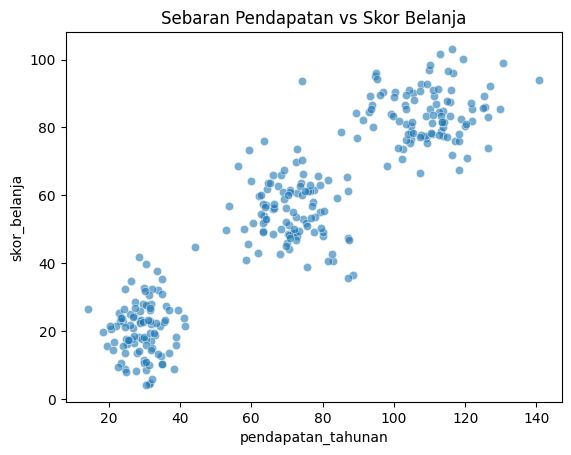

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Generate dataset sintetis pelanggan (3 kelompok tersembunyi)
np.random.seed(42)

grp1 = np.random.normal([30, 20], [6, 8], (100, 2))    # hemat
grp2 = np.random.normal([70, 55], [8, 10], (100, 2))   # menengah
grp3 = np.random.normal([110, 85], [10, 8], (100, 2))  # boros

data = np.vstack([grp1, grp2, grp3])

df = pd.DataFrame(data, columns=['pendapatan_tahunan', 'skor_belanja'])
df['usia'] = np.random.randint(18, 65, len(df))
df['gender'] = np.random.choice(['L', 'P'], len(df))

print('Shape:', df.shape)
print(df.describe().round(2))

sns.scatterplot(data=df, x='pendapatan_tahunan', y='skor_belanja', alpha=0.6)
plt.title('Sebaran Pendapatan vs Skor Belanja')
plt.show()

In [2]:
from sklearn.preprocessing import StandardScaler

X = df[['pendapatan_tahunan', 'skor_belanja']].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Rata-rata setelah scaling:', X_scaled.mean(axis=0).round(3))
print('Std setelah scaling :', X_scaled.std(axis=0).round(3))

Rata-rata setelah scaling: [-0.  0.]
Std setelah scaling : [1. 1.]


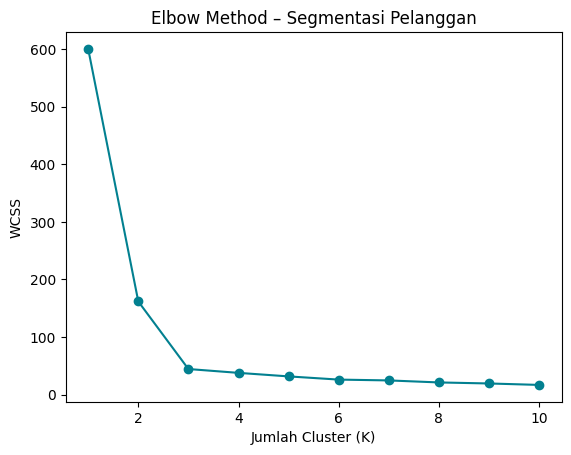

In [3]:
from sklearn.cluster import KMeans

wcss = []

for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42, init='k-means++')
    km.fit(X_scaled)
    wcss.append(km.inertia_)

plt.plot(range(1, 11), wcss, marker='o', color='#028090')
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('WCSS')
plt.title('Elbow Method – Segmentasi Pelanggan')
plt.show()

### Interpretasi Metode Elbow

Berdasarkan grafik Elbow, penurunan nilai WCSS sangat signifikan dari **K=1** hingga **K=3**, kemudian kurva mulai melandai setelah **K=3**. Hal ini menunjukkan bahwa **titik elbow berada pada K=3**, sehingga jumlah cluster yang optimal adalah **3 cluster**.

Hasil tersebut juga **sesuai dengan dataset sintetis** yang memang dibuat memiliki **tiga kelompok pelanggan tersembunyi** (hemat, menengah, dan boros). Oleh karena itu, nilai **K=3** dipilih sebagai jumlah cluster yang akan digunakan pada proses K-Means.

In [4]:
from sklearn.metrics import silhouette_score

model = KMeans(n_clusters=3, random_state=42, init='k-means++')
model.fit(X_scaled)

df['cluster'] = model.labels_

print(f'WCSS akhir      : {model.inertia_:.3f}')
print(f'Silhouette Score: {silhouette_score(X_scaled, model.labels_):.3f}')

print(df.groupby('cluster')[['pendapatan_tahunan', 'skor_belanja']].mean().round(2))

WCSS akhir      : 44.556
Silhouette Score: 0.695
         pendapatan_tahunan  skor_belanja
cluster                                  
0                     70.99         55.05
1                     29.31         20.27
2                    109.20         84.08


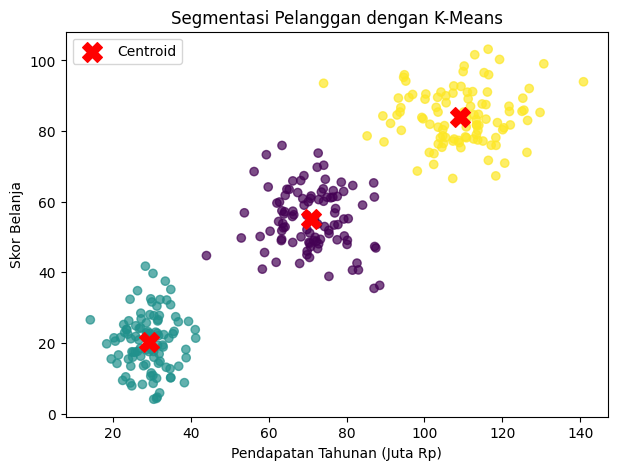

In [5]:
centroids = scaler.inverse_transform(model.cluster_centers_)

plt.figure(figsize=(7, 5))

plt.scatter(
    df['pendapatan_tahunan'],
    df['skor_belanja'],
    c=df['cluster'],
    cmap='viridis',
    alpha=0.7
)

plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    c='red',
    marker='X',
    s=200,
    label='Centroid'
)

plt.xlabel('Pendapatan Tahunan (Juta Rp)')
plt.ylabel('Skor Belanja')
plt.title('Segmentasi Pelanggan dengan K-Means')
plt.legend()
plt.show()

### Interpretasi Hasil Clustering

Berdasarkan hasil K-Means dengan **K = 3**, diperoleh **WCSS sebesar 44.556** dan **Silhouette Score sebesar 0.695**. Nilai Silhouette Score yang mendekati 1 menunjukkan bahwa kualitas clustering tergolong baik, di mana anggota dalam setiap cluster cukup kompak dan memiliki pemisahan yang jelas dengan cluster lainnya.

Visualisasi menunjukkan bahwa data berhasil terbagi menjadi tiga kelompok yang terpisah dengan jelas, serta posisi centroid berada di pusat masing-masing cluster. Hal ini mengindikasikan bahwa model K-Means mampu menemukan pola segmentasi pelanggan sesuai dengan karakteristik data.

Karakteristik masing-masing cluster adalah sebagai berikut:
- **Cluster 1** memiliki rata-rata pendapatan tahunan sekitar **29,31 juta rupiah** dan skor belanja **20,27**, sehingga dapat diinterpretasikan sebagai segmen **"Hemat"**, yaitu pelanggan dengan pendapatan dan tingkat belanja rendah.
- **Cluster 0** memiliki rata-rata pendapatan tahunan sekitar **70,99 juta rupiah** dan skor belanja **55,05**, sehingga termasuk segmen **"Menengah"**, yaitu pelanggan dengan pendapatan dan pola belanja sedang.
- **Cluster 2** memiliki rata-rata pendapatan tahunan sekitar **109,20 juta rupiah** dan skor belanja **84,08**, sehingga termasuk segmen **"Boros/Premium"**, yaitu pelanggan dengan pendapatan tinggi dan tingkat belanja tinggi.

Secara keseluruhan, hasil clustering sesuai dengan karakteristik dataset sintetis yang sejak awal dibangun memiliki tiga kelompok pelanggan, sehingga model K-Means berhasil mengidentifikasi ketiga segmen tersebut dengan baik.

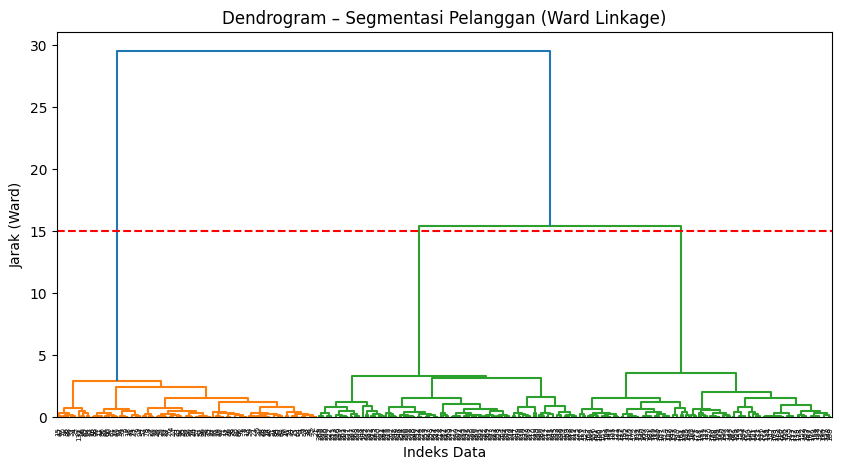

In [6]:
from scipy.cluster.hierarchy import dendrogram
from scipy.cluster.hierarchy import linkage

Z = linkage(X_scaled, method='ward')

plt.figure(figsize=(10, 5))
dendrogram(Z)

plt.title('Dendrogram – Segmentasi Pelanggan (Ward Linkage)')
plt.xlabel('Indeks Data')
plt.ylabel('Jarak (Ward)')

plt.axhline(y=15, color='red', linestyle='--')  # contoh garis potong

plt.show()

### Perbandingan Hierarchical Clustering dengan K-Means

Berdasarkan dendrogram dengan metode **Ward Linkage**, jika garis potong ditempatkan pada **jarak (Ward) sekitar 15**, data terbagi menjadi **3 cluster**. Hal ini terlihat dari tiga kelompok utama yang terbentuk sebelum terjadi penggabungan pada jarak yang lebih tinggi.

Hasil tersebut **konsisten dengan hasil Metode Elbow** pada Langkah 3 yang juga menunjukkan bahwa jumlah cluster optimal adalah **K = 3**. Dengan demikian, baik metode **K-Means** maupun **Hierarchical Clustering** memberikan hasil segmentasi yang sama, sehingga semakin menguatkan bahwa dataset sintetis ini memang memiliki tiga kelompok pelanggan yang berbeda.

Secara keseluruhan, kedua metode berhasil mengidentifikasi tiga segmen pelanggan, yaitu pelanggan dengan **pendapatan dan skor belanja rendah (Hemat)**, **pendapatan dan skor belanja menengah (Menengah)**, serta **pendapatan dan skor belanja tinggi (Boros/Premium)**.

## Kesimpulan

Pada Pertemuan 11 dilakukan **segmentasi pelanggan menggunakan algoritma K-Means Clustering**. Dataset sintetis terdiri dari **300 pelanggan** dengan atribut utama berupa **pendapatan tahunan** dan **skor belanja**. Data kemudian dilakukan standardisasi agar kedua fitur memiliki skala yang sebanding. 

Hasil clustering menghasilkan **3 kelompok pelanggan** dengan karakteristik:

| Cluster   | Pendapatan Tahunan | Skor Belanja | Karakteristik      |
| --------- | -----------------: | -----------: | ------------------ |
| Cluster 0 |              70,99 |        55,05 | Pelanggan menengah |
| Cluster 1 |              29,31 |        20,27 | Pelanggan hemat    |
| Cluster 2 |             109,20 |        84,08 | Pelanggan boros    |

Nilai evaluasi clustering yang diperoleh adalah:

* **WCSS:** 44,556
* **Silhouette Score:** 0,695 

K-Means berhasil membagi pelanggan menjadi **3 segmen yang cukup jelas**, yaitu pelanggan hemat, menengah, dan boros. Nilai **Silhouette Score 0,695** menunjukkan bahwa hasil clustering memiliki pemisahan kelompok yang cukup baik. Segmentasi ini dapat digunakan untuk menentukan strategi pemasaran yang berbeda sesuai karakteristik setiap kelompok pelanggan.
